<a href="https://colab.research.google.com/github/Fahrisetiadarma/DataAnalytics/blob/main/Clustering/BMHP_Prediction%26Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [ ]:
file_path = '/content/drive/My Drive/dataskripsi4.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')
df

,Nama_Barang,January,February,March,April,May,June,July,August,September,October,November,December,Jenis_BMHP,Departemen_Pengguna,Pola_Permintaan,Kategori_BMHP,avg,Cluster
0,Spuit 1 cc,147900,93000,128000,78000,95000,115900,12700,20500,190900,16500,11500,12000,Medis,"Bedah, IGD, Rawat Jalan",Tidak Terduga,Jarum Suntik,76825.000000,0
1,Spuit 3 cc,513200,448500,469500,438900,457100,411400,412900,445600,513400,585200,524300,503800,Medis,"Bedah, IGD, Rawat Jalan",Stabil,Jarum Suntik,476983.333333,0
2,Spuit 5 cc,152200,122600,148800,123900,144300,118800,127600,113200,154100,137400,114500,113700,Medis,"Bedah, IGD, Rawat Jalan",Stabil,Jarum Suntik,130925.000000,0
3,Spuit 10 cc,119200,97700,114300,116800,124500,99400,86200,100000,140600,162000,135300,112700,Medis,"Bedah, IGD, Rawat Jalan",Stabil,Jarum Suntik,117391.666667,0
4,Spuit 50 cc,48000,282000,448000,349000,25000,334000,270000,322000,278000,433000,125000,61000,Medis,"Bedah, IGD, Rawat Jalan",Tidak Terduga,Jarum Suntik,247916.666667,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,Lampu Operasi,16900,45800,37300,34800,17400,22000,10700,34400,23900,15300,85000,21000,Medis,Bedah,Stabil,Alat Laboratorium & Diagnostik,30375.000000,0
99,Pinset Anatomis,20500,42600,12800,37200,18200,23100,41900,26200,29800,37800,18900,46400,Medis,"Rawat Jalan, Bedah",Stabil,Alat Laboratorium & Diagnostik,29616.666667,0
100,Gunting Bedah,55000,23900,35800,32100,16300,45900,43700,68000,46000,23300,36600,26500,Medis,"ICU, Bedah",Tidak Terduga,Alat Laboratorium & Diagnostik,37758.333333,0
101,Blade Scalpel,29700,20200,31000,37400,62000,41600,49700,10300,11900,25200,39000,44700,Medis,Bedah,Stabil,Alat Laboratorium & Diagnostik,33558.333333,0


In [ ]:
df.info()
df=df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Nama_Barang          103 non-null    object 
 1   January              103 non-null    int64  
 2   February             103 non-null    int64  
 3   March                103 non-null    int64  
 4   April                103 non-null    int64  
 5   May                  103 non-null    int64  
 6   June                 103 non-null    int64  
 7   July                 103 non-null    int64  
 8   August               103 non-null    int64  
 9   September            103 non-null    int64  
 10  October              103 non-null    int64  
 11  November             103 non-null    int64  
 12  December             103 non-null    int64  
 13  Jenis_BMHP           103 non-null    object 
 14  Departemen_Pengguna  103 non-null    object 
 15  Pola_Permintaan      103 non-null    obj

In [ ]:
drop_data= df.dropna()
drop_data.isna().sum()

,0
Nama_Barang,0
January,0
February,0
March,0
April,0
May,0
June,0
July,0
August,0
September,0


In [ ]:
columns_to_scale = ['avg', 'Jenis_BMHP']
numerical_cols = ['avg']
categorical_cols = ['Jenis_BMHP']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
encoded_columns_to_scale = [col for col in df_encoded.columns if col in numerical_cols or any(cat in col for cat in categorical_cols)]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded[encoded_columns_to_scale])

In [ ]:
model_final = AgglomerativeClustering(n_clusters=3)
df['Cluster'] = model_final.fit_predict(X_scaled)

In [ ]:
score = silhouette_score(X_scaled, df['Cluster'])

In [ ]:
cluster_counts = df['Cluster'].value_counts().sort_index()
evaluation_table = pd.DataFrame({
    'Cluster': cluster_counts.index,
    'Jumlah Item': cluster_counts.values,
    'Silhouette Score': [score] * len(cluster_counts)
})

print(evaluation_table.to_string(index=False))

 Cluster  Jumlah Item  Silhouette Score
       0           77          0.725266
       1           24          0.725266
       2            2          0.725266


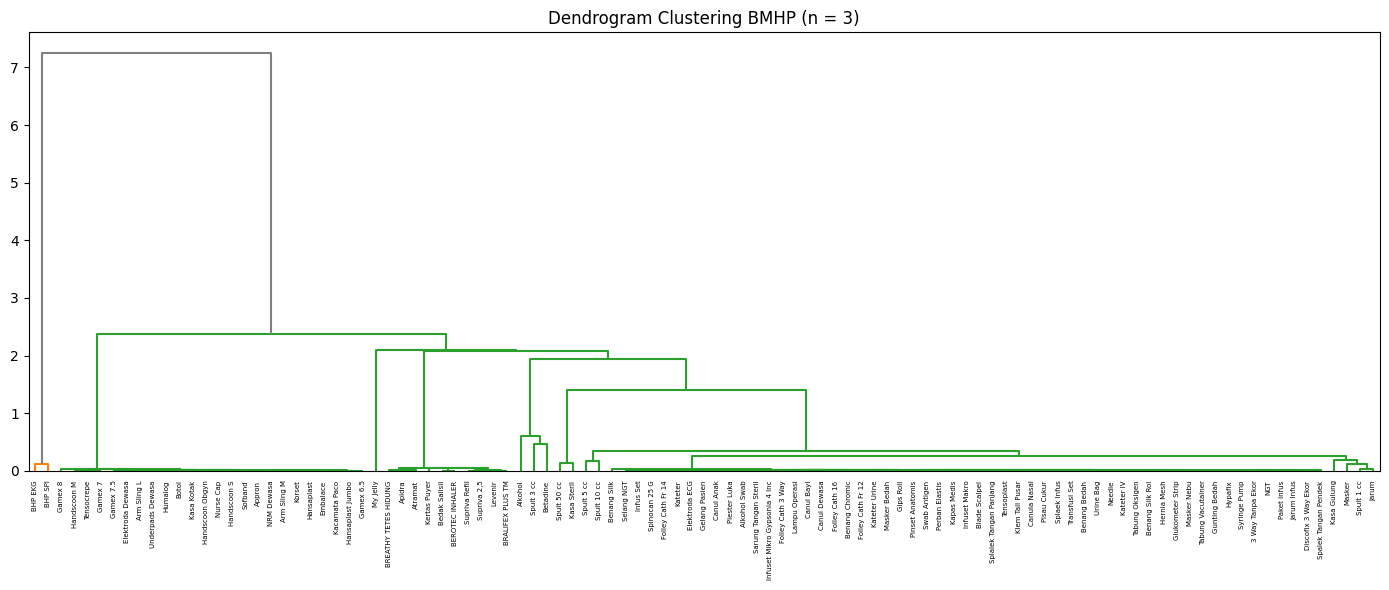

In [ ]:
linked = linkage(X_scaled, method='single')
plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    labels=df['Nama_Barang'].values,
    orientation='top',
    color_threshold=None,
    above_threshold_color='grey'
)
plt.title(f'Dendrogram Clustering BMHP (n = {3})')
plt.tight_layout()
plt.show()

/tmp/ipython-input-56-3828712476.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Cluster', palette='Set2')


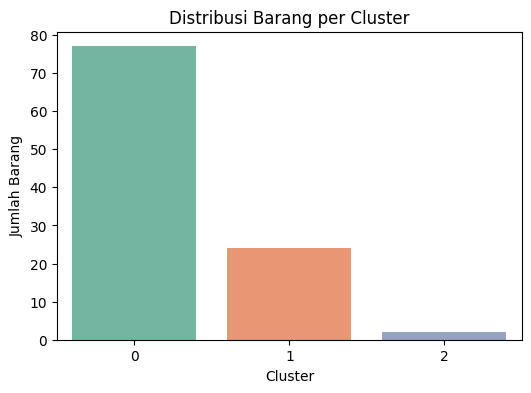

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Cluster', palette='Set2')
plt.title('Distribusi Barang per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Barang')
plt.show()

In [ ]:
tabel_klaster = df[['Nama_Barang', 'Cluster']]
display(tabel_klaster)

,Nama_Barang,Cluster
0,Spuit 1 cc,0
1,Spuit 3 cc,0
2,Spuit 5 cc,0
3,Spuit 10 cc,0
4,Spuit 50 cc,0
...,...,...
98,Lampu Operasi,0
99,Pinset Anatomis,0
100,Gunting Bedah,0
101,Blade Scalpel,0


In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Global list untuk menampung hasil forecast per barang
forecast_per_barang = []

def plot_and_evaluate_forecasting_per_cluster(df, cluster_id):
    df_cluster = df[df['Cluster'] == cluster_id]
    print(f"\n{'='*50}\nCluster {cluster_id} - Jumlah Item: {len(df_cluster)}\n{'='*50}")

    bulan = ['January', 'February', 'March', 'April', 'May', 'June',
             'July', 'August', 'September', 'October', 'November', 'December']

    error_mae, error_mape, forecast_list = [], [], []

    for _, row in df_cluster.iterrows():
        usage = row[bulan].astype(float).values
        nama_barang = row['Nama_Barang']

        model = SimpleExpSmoothing(usage[:-1], initialization_method="heuristic")
        fit = model.fit(smoothing_level=0.8, optimized=False)
        forecast = fit.forecast(1)[0]

        actual = usage[-1]
        mae = abs(actual - forecast)
        mape = abs(actual - forecast) / actual * 100 if actual != 0 else np.nan

        error_mae.append(mae)
        error_mape.append(mape)
        forecast_list.append({'Nama_Barang': nama_barang, 'Forecast': forecast, 'Usage': usage})

        forecast_per_barang.append({
            'Nama_Barang': nama_barang,
            'Cluster': cluster_id,
            'SES_Prediction': forecast,
            'SES_MAE': mae,
            'SES_MAPE': mape
        })

    # Tertinggi dan terendah
    df_forecast = pd.DataFrame(forecast_list)
    max_row = df_forecast.loc[df_forecast['Forecast'].idxmax()]
    min_row = df_forecast.loc[df_forecast['Forecast'].idxmin()]
    nama_max = max_row['Nama_Barang']
    nama_min = min_row['Nama_Barang']

    result_table = pd.DataFrame([
        {'Tipe': 'Tertinggi', 'Nama_Barang': nama_max, 'Forecast': max_row['Forecast']},
        {'Tipe': 'Terendah',  'Nama_Barang': nama_min, 'Forecast': min_row['Forecast']}
    ])
    print(f"\n--- Forecast Tertinggi dan Terendah di Cluster {cluster_id} ---")
    print(result_table.to_string(index=False))

    # 🔵 Visualisasi grafik
    plt.figure(figsize=(16, 7))
    colors = plt.cm.tab20.colors
    for i, row in enumerate(forecast_list):
        usage = row['Usage']
        nama_barang = row['Nama_Barang']
        forecast = row['Forecast']

        x_vals = list(range(1, 14))  # 1-12 + forecast
        y_vals = list(usage) + [forecast]
        color = colors[i % len(colors)]

        label = ''
        if nama_barang in [nama_max, nama_min]:
            label = f"{nama_barang} ({forecast:.1f})"

        plt.plot(x_vals, y_vals,
                 linewidth=2 if nama_barang in [nama_max, nama_min] else 1,
                 alpha=0.9 if nama_barang in [nama_max, nama_min] else 0.4,
                 color=color,
                 label=label)

        if nama_barang in [nama_max, nama_min]:
            plt.plot(13, forecast, marker='*', color=color, markersize=12)
            plt.text(13.1, forecast, f"{forecast:.1f}", fontsize=9, color=color)

    # Dekorasi
    plt.axvline(x=12.5, color='gray', linestyle='--', linewidth=1.3, label='Batas Forecast')
    plt.axvspan(12.5, 13.5, color='orange', alpha=0.1)
    plt.xticks(range(1, 14), labels=[*range(1, 13), 'Forecast'])

    plt.title(f"Tren Forecast - Cluster {cluster_id}", fontsize=16, fontweight='bold')
    plt.xlabel("Bulan", fontsize=12)
    plt.ylabel("Jumlah Penggunaan", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9, title='Barang Forecast Tertinggi & Terendah')
    plt.figtext(0.9, 0.02, f"Total Barang: {len(df_cluster)}", ha='right', fontsize=10, style='italic')
    plt.show()

    # Evaluasi cluster
    avg_mae = np.nanmean(error_mae)
    avg_mape = np.nanmean(error_mape)
    print(f"\n>>> Rata-rata MAE Cluster {cluster_id}: {avg_mae:.2f}")
    print(f">>> Rata-rata MAPE Cluster {cluster_id}: {avg_mape:.2f}%")

    return avg_mae, avg_mape, result_table



Cluster 0 - Jumlah Item: 77

--- Forecast Tertinggi dan Terendah di Cluster 0 ---
     Tipe  Nama_Barang      Forecast
Tertinggi   Spuit 3 cc 533015.564569
 Terendah Alkohol Swab  13236.192864


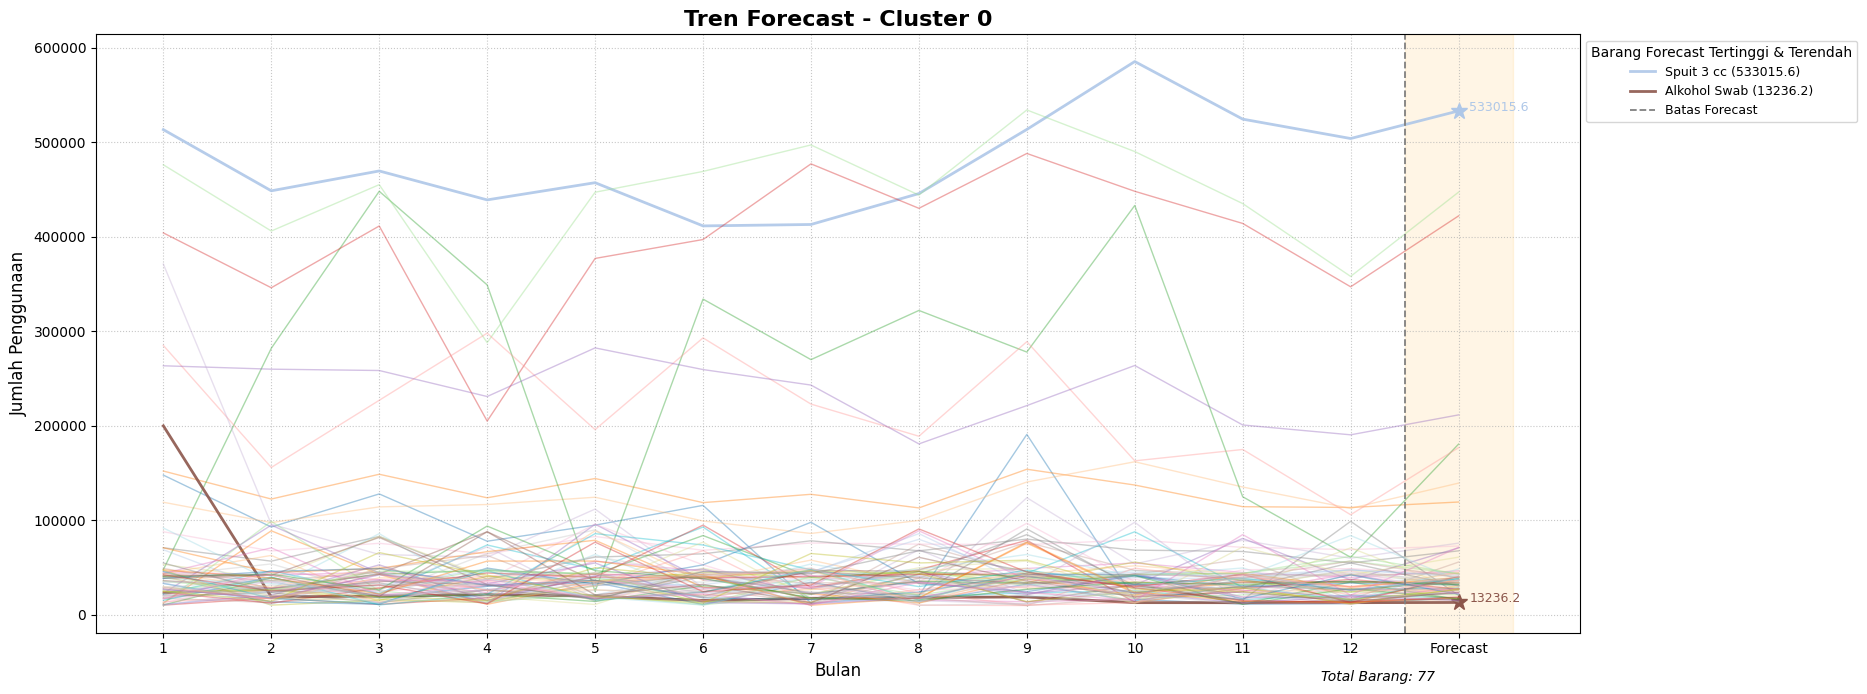


>>> Rata-rata MAE Cluster 0: 18733.58
>>> Rata-rata MAPE Cluster 0: 52.39%

Cluster 1 - Jumlah Item: 24

--- Forecast Tertinggi dan Terendah di Cluster 1 ---
     Tipe      Nama_Barang     Forecast
Tertinggi Underpads Dewasa 79950.196346
 Terendah        Gamex 7.5 18317.953163


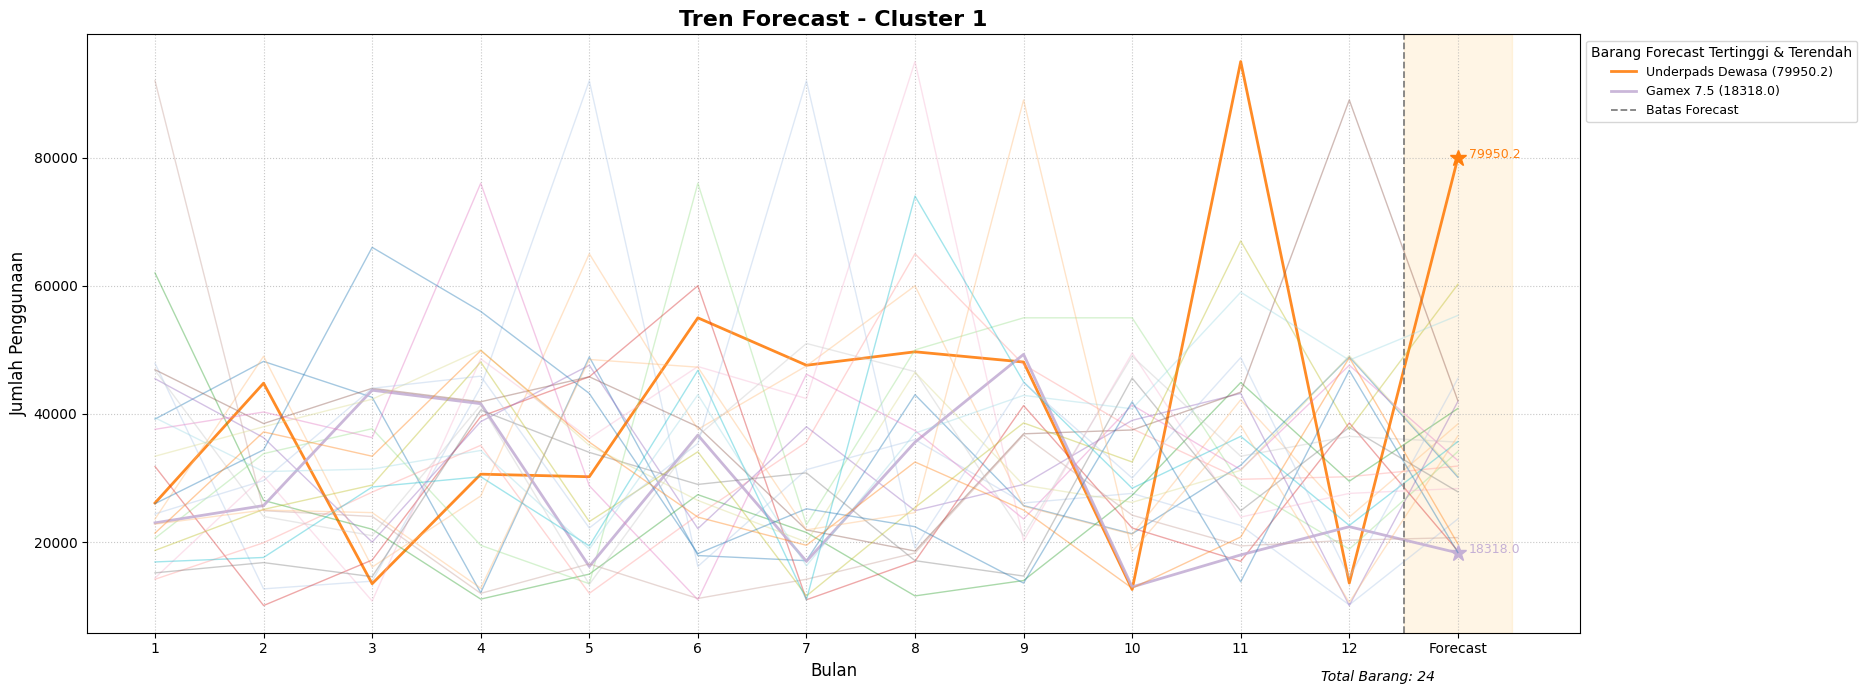


>>> Rata-rata MAE Cluster 1: 18625.76
>>> Rata-rata MAPE Cluster 1: 87.33%

Cluster 2 - Jumlah Item: 2

--- Forecast Tertinggi dan Terendah di Cluster 2 ---
     Tipe Nama_Barang     Forecast
Tertinggi     BHP EKG 31827.699766
 Terendah     BHP SPI 28874.831479


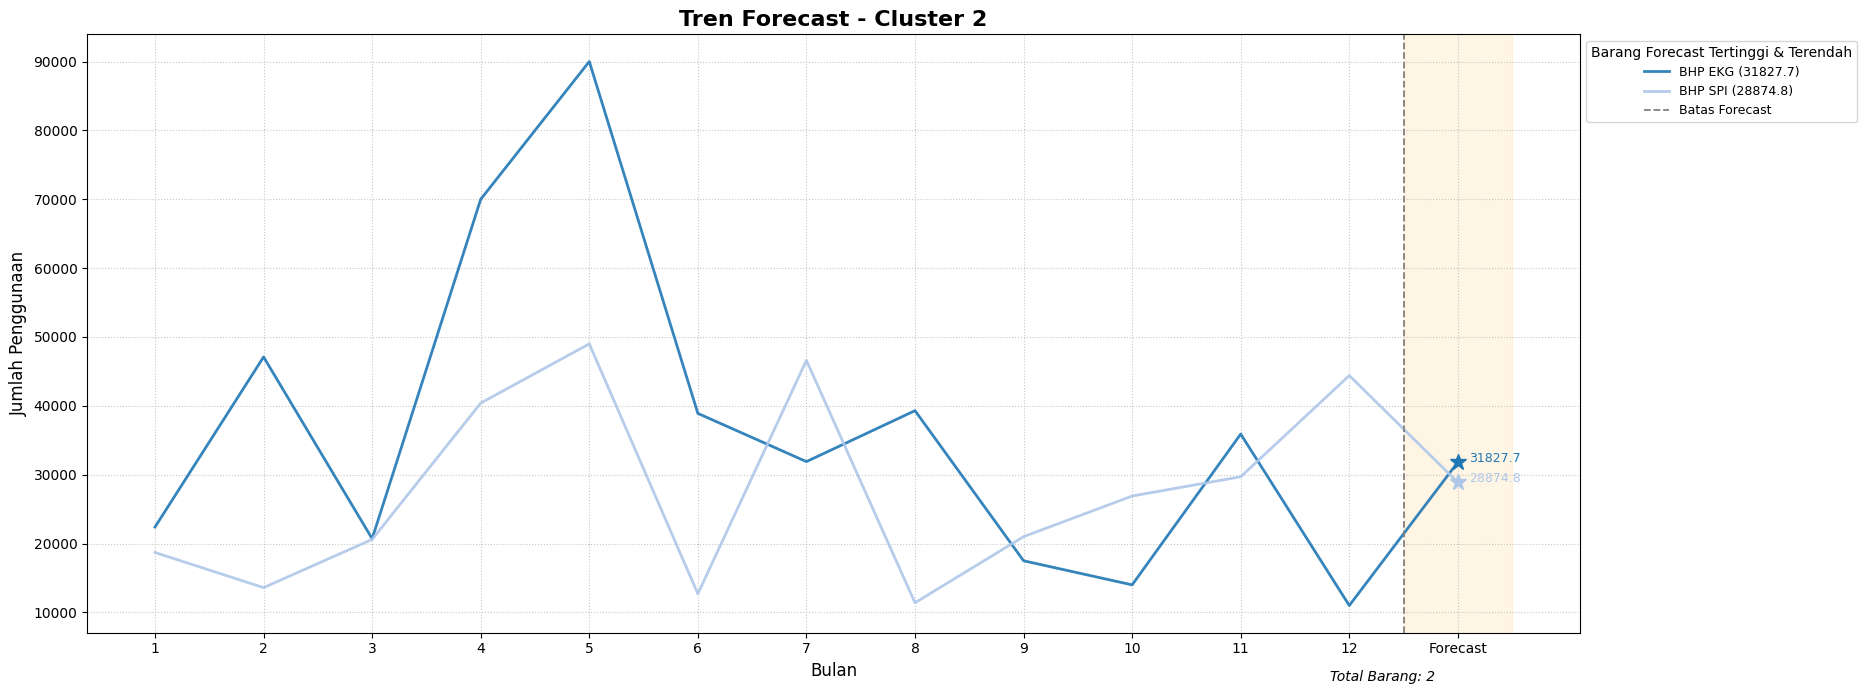


>>> Rata-rata MAE Cluster 2: 18176.43
>>> Rata-rata MAPE Cluster 2: 112.15%


In [ ]:
# Loop semua cluster
for cluster_id in sorted(df['Cluster'].unique()):
    avg_mae, avg_mape, result_table = plot_and_evaluate_forecasting_per_cluster(df, cluster_id)

# Buat DataFrame dari hasil forecast seluruh barang
df_cluster_ses = pd.DataFrame(forecast_per_barang)


In [ ]:
# Setelah seluruh cluster diproses
df_cluster_ses = pd.DataFrame(forecast_per_barang)

# Hitung buffer berdasarkan MAPE
def tentukan_buffer(mape):
    if pd.isna(mape):
        return 0.1
    elif mape >= 50:
        return 0.3
    elif mape >= 20:
        return 0.2
    else:
        return 0.1

df_cluster_ses['Buffer_%'] = df_cluster_ses['SES_MAPE'].apply(tentukan_buffer)
df_cluster_ses['Recommended_Stock'] = df_cluster_ses['SES_Prediction'] * (1 + df_cluster_ses['Buffer_%'])

# Tampilkan rekomendasi stok
print("\n📦 Rekomendasi Stok per Barang:")
display(df_cluster_ses[['Nama_Barang', 'SES_Prediction', 'SES_MAE', 'SES_MAPE', 'Buffer_%', 'Recommended_Stock']])



📦 Rekomendasi Stok per Barang:


,Nama_Barang,SES_Prediction,SES_MAE,SES_MAPE,Buffer_%,Recommended_Stock
0,Spuit 1 cc,18131.904139,6131.904139,51.099201,0.3,23571.475380
1,Spuit 3 cc,533015.564569,29215.564569,5.799040,0.1,586317.121026
2,Spuit 5 cc,119442.447946,5742.447946,5.050526,0.1,131386.692740
3,Spuit 10 cc,139442.838739,26742.838739,23.729227,0.2,167331.406487
4,Spuit 50 cc,180673.798450,119673.798450,196.186555,0.3,234875.937985
...,...,...,...,...,...,...
99,Nurse Cap,45527.573959,31027.573959,213.983269,0.3,59185.846146
100,Arm Sling L,19729.498270,29070.501730,59.570700,0.3,25648.347751
101,Arm Sling M,36568.257949,25968.257949,244.983566,0.3,47538.735334
102,BHP EKG,31827.699766,20827.699766,189.342725,0.3,41376.009695


In [ ]:
print("\n📦 Rekomendasi Stok per Cluster:")
display(df_cluster_ses[['SES_Prediction', 'SES_MAPE', 'Buffer_%', 'Recommended_Stock']])


📦 Rekomendasi Stok per Cluster:


,SES_Prediction,SES_MAPE,Buffer_%,Recommended_Stock
0,18131.904139,51.099201,0.3,23571.475380
1,533015.564569,5.799040,0.1,586317.121026
2,119442.447946,5.050526,0.1,131386.692740
3,139442.838739,23.729227,0.2,167331.406487
4,180673.798450,196.186555,0.3,234875.937985
...,...,...,...,...
99,45527.573959,213.983269,0.3,59185.846146
100,19729.498270,59.570700,0.3,25648.347751
101,36568.257949,244.983566,0.3,47538.735334
102,31827.699766,189.342725,0.3,41376.009695


In [ ]:
# Hapus kolom lama jika sudah ada
columns_to_drop = ['SES_Prediction', 'SES_MAE', 'SES_MAPE', 'Recommended_Stock']
df = df.drop(columns=columns_to_drop, errors='ignore')

# Gabungkan berdasarkan 'Nama_Barang' (bukan Cluster!)
df = df.merge(df_cluster_ses[['Nama_Barang', 'SES_Prediction', 'SES_MAE', 'SES_MAPE', 'Recommended_Stock']],
              on='Nama_Barang', how='left')

# Simpan ke Excel
output = df[['Nama_Barang', 'Kategori_BMHP', 'Jenis_BMHP', 'Departemen_Pengguna',
             'Cluster', 'SES_Prediction', 'SES_MAE', 'SES_MAPE', 'Recommended_Stock']]

output.to_excel('/content/drive/My Drive/hasil rekomendasi.xlsx', index=False)
print("✅ Output berhasil disimpan ke Drive.")


✅ Output berhasil disimpan ke Drive.
